# AadhaarVista: Aadhaar Enrolment & Update Intelligence

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [69]:
# Enrolment dataset
enrolment = [
    "api_data_aadhar_enrolment_0_500000.csv",
    "api_data_aadhar_enrolment_500000_1000000.csv",
    "api_data_aadhar_enrolment_1000000_1006029.csv"
]

enrolment_df = pd.concat(
    [pd.read_csv(file) for file in enrolment],
    ignore_index = True
)

enrolment_df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [70]:
# Biometric dataset
biometric =  [
    "api_data_aadhar_biometric_0_500000.csv",
    "api_data_aadhar_biometric_500000_1000000.csv",
    "api_data_aadhar_biometric_1000000_1500000.csv",
    "api_data_aadhar_biometric_1500000_1861108.csv"
]

biometric_df = pd.concat(
    [pd.read_csv(file) for file in biometric],
    ignore_index = True
)

biometric_df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [71]:
# Demographic dataset
demographic =  [
    "api_data_aadhar_demographic_0_500000.csv",
    "api_data_aadhar_demographic_500000_1000000.csv",
    "api_data_aadhar_demographic_1000000_1500000.csv",
    "api_data_aadhar_demographic_1500000_2000000.csv",
    "api_data_aadhar_demographic_2000000_2071700.csv",
]

demographic_df = pd.concat(
    [pd.read_csv(file) for file in demographic],
    ignore_index = True
)

demographic_df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785


In [109]:
print("Enrolment Data:", enrolment_df.shape)
print("Biometric Data:", biometric_df.shape)
print("Demographic Data:", demographic_df.shape)

print("\n")

print(enrolment_df.columns, "\n")
print(biometric_df.columns, "\n")
print(demographic_df.columns, "\n")

Enrolment Data: (1006029, 8)
Biometric Data: (1861108, 6)
Demographic Data: (2071700, 6)


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater', 'score'],
      dtype='object') 

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object') 

Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object') 



In [44]:
enrolment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB


In [45]:
# Unique geographic coverage
enrolment_df['state'].nunique(), enrolment_df['district'].nunique()

(55, 985)

In [46]:
# Date range
enrolment_df['date'].min(), enrolment_df['date'].max()

('01-04-2025', '31-12-2025')

In [28]:
# Description Of Enrolment
enrolment_df[['age_0_5','age_5_17','age_18_greater']].describe()

,age_0_5,age_5_17,age_18_greater
count,1.006029e+06,1.006029e+06,1.006029e+06
mean,3.525709e+00,1.710074e+00,1.673441e-01
std,1.753851e+01,1.436963e+01,3.220525e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,0.000000e+00
75%,3.000000e+00,1.000000e+00,0.000000e+00
max,2.688000e+03,1.812000e+03,8.550000e+02


In [29]:
# Description Of Biometric
biometric_df[['bio_age_5_17','bio_age_17_']].describe()

,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06
mean,1.839058e+01,1.909413e+01
std,8.370421e+01,8.806502e+01
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00
50%,3.000000e+00,4.000000e+00
75%,1.100000e+01,1.000000e+01
max,8.002000e+03,7.625000e+03


In [30]:
# Description Of Demographic
demographic_df[['demo_age_5_17','demo_age_17_']].describe()

,demo_age_5_17,demo_age_17_
count,2.071700e+06,2.071700e+06
mean,2.347552e+00,2.144701e+01
std,1.490355e+01,1.252498e+02
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.000000e+00
50%,1.000000e+00,6.000000e+00
75%,2.000000e+00,1.500000e+01
max,2.690000e+03,1.616600e+04


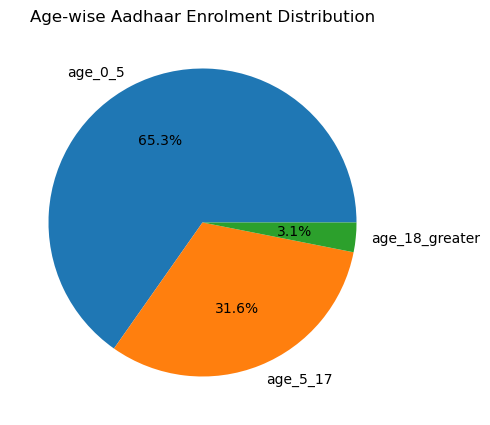

In [64]:
#Age-wise Aadhaar Enrolment Distribution

enrolment_total = enrolment_df[['age_0_5','age_5_17','age_18_greater']].sum()

plt.figure(figsize=(5,5))
plt.pie(enrolment_total, labels=enrolment_total.index, autopct='%1.1f%%')
plt.title("Age-wise Aadhaar Enrolment Distribution")
plt.show()

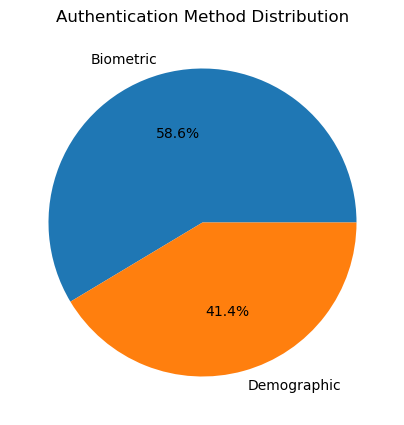

In [62]:
#Authentication Method Distribution (biometric vs demographic)

auth_totals = {
    'Biometric': biometric_df[['bio_age_5_17','bio_age_17_']].sum().sum(),
    'Demographic': demographic_df[['demo_age_5_17','demo_age_17_']].sum().sum()
}

plt.figure(figsize=(5,5))
plt.pie(auth_totals.values(), labels=auth_totals.keys(), autopct='%1.1f%%')
plt.title("Authentication Method Distribution")
plt.show()


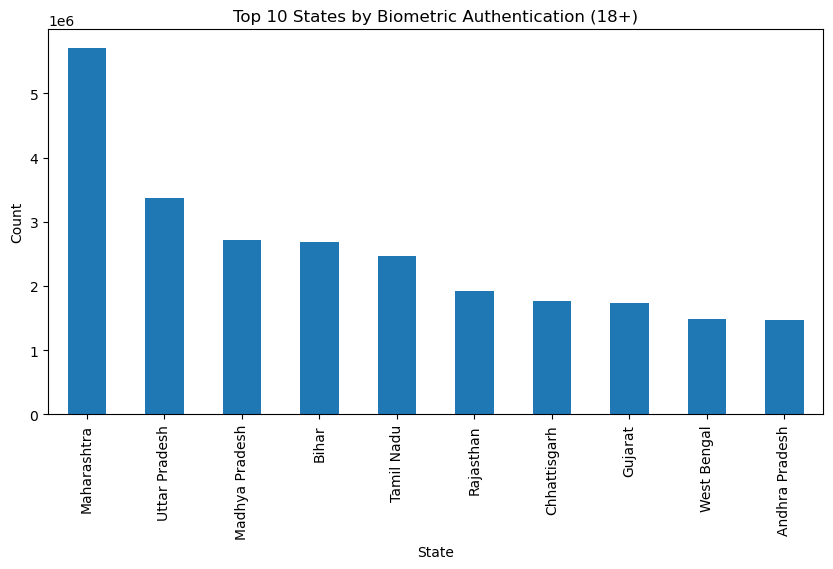

In [63]:
#Top 10 States by Biometric Authentication (18+)

top_states_bio = biometric_df.groupby('state')['bio_age_17_'] \
                       .sum() \
                       .sort_values(ascending=False) \
                       .head(10)

top_states_bio.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Biometric Authentication (18+)")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()


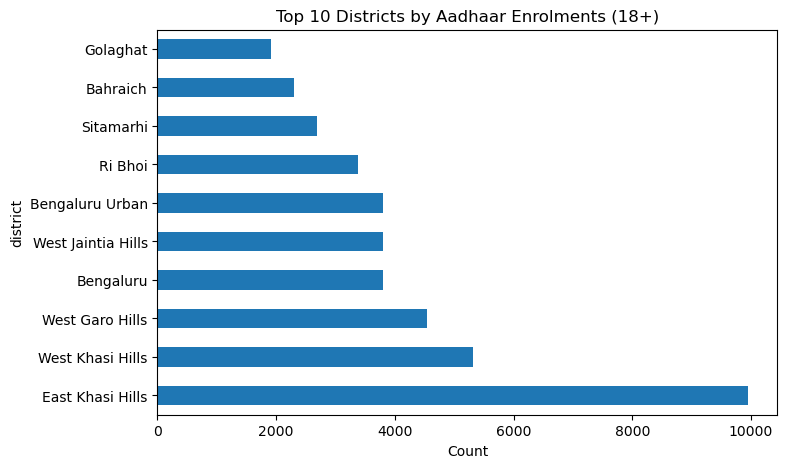

In [73]:
#Top 10 Districts by Aadhaar Enrolments (18+)

top_districts = enrolment_df.groupby('district')['age_18_greater'] \
                      .sum() \
                      .sort_values(ascending=False) \
                      .head(10)

top_districts.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Districts by Aadhaar Enrolments (18+)")
plt.xlabel("Count")
plt.show()


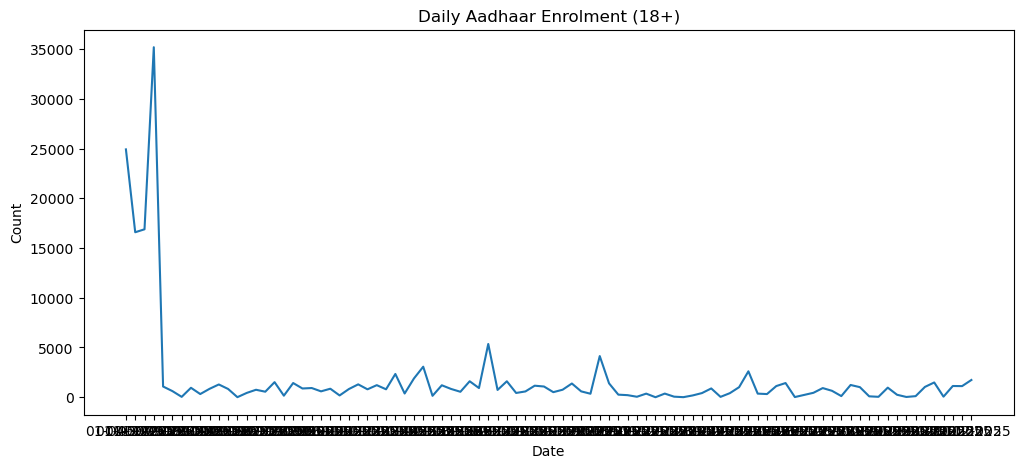

In [74]:
#Daily Aadhaar Enrolment (18+)

daily = enrolment_df.groupby('date')['age_18_greater'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily)
plt.title("Daily Aadhaar Enrolment (18+)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()


Text(0.5, 1.0, 'Quarterly Aadhaar Enrolment Trends by Age Group')

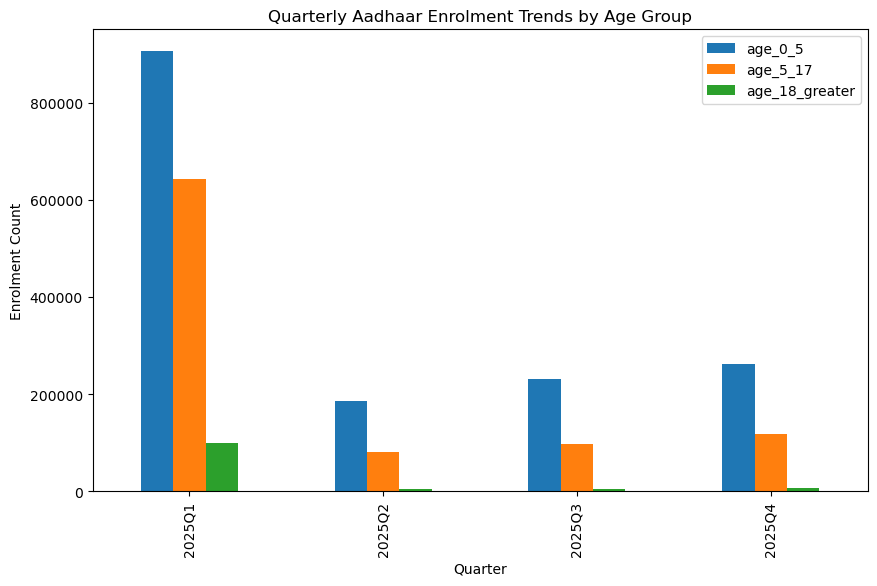

In [114]:
# Quarterly Aadhaar Enrolment Trends by Age Group
quarterly = enrolment_df.groupby(enrolment_df['date'].dt.to_period('Q'))[
    ['age_0_5','age_5_17','age_18_greater']
].sum()

quarterly.plot(kind='bar', figsize=(10,6))
plt.xlabel("Quarter")
plt.ylabel("Enrolment Count")
plt.title("Quarterly Aadhaar Enrolment Trends by Age Group")


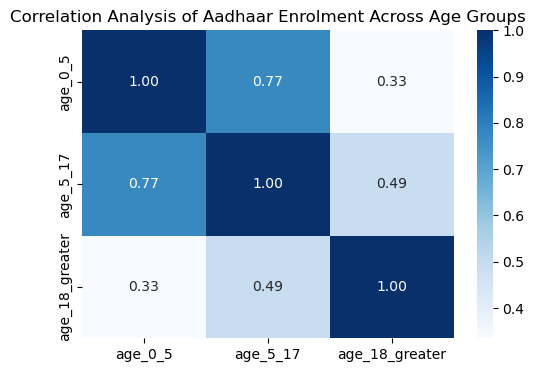

In [115]:
# Correlation Analysis of Aadhaar Enrolment Across Age Groups
corr = enrolment_df[['age_0_5','age_5_17','age_18_greater']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Analysis of Aadhaar Enrolment Across Age Groups")
plt.show()


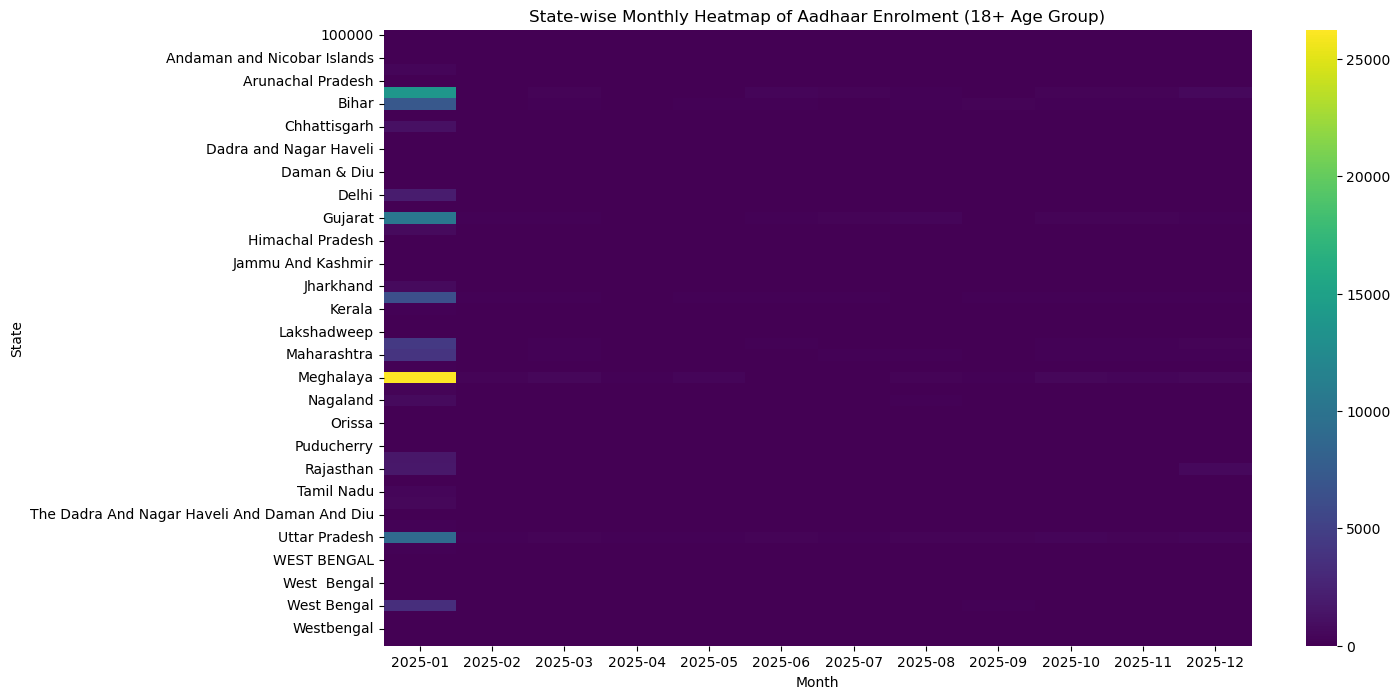

In [116]:
#State-wise Monthly Heatmap of Aadhaar Enrolment (18+ Age Group)
state_monthly = enrolment_df.groupby(
    ['state', enrolment_df['date'].dt.to_period('M')]
)['age_18_greater'].sum().unstack(fill_value=0)

plt.figure(figsize=(14,8))
sns.heatmap(state_monthly, cmap='viridis')
plt.title("State-wise Monthly Heatmap of Aadhaar Enrolment (18+ Age Group)")
plt.xlabel("Month")
plt.ylabel("State")
plt.show()


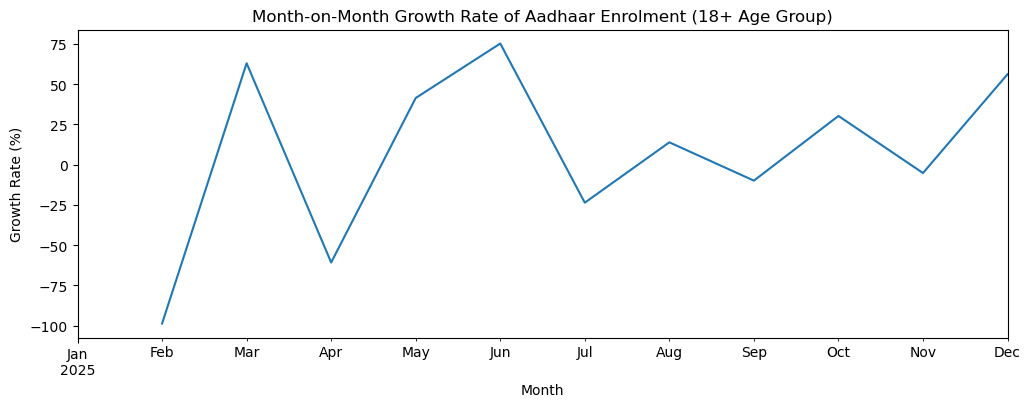

In [117]:
# Month-on-Month Growth Rate of Aadhaar Enrolment (18+ Age Group)
monthly_total = enrolment_df.groupby(
    enrolment_df['date'].dt.to_period('M')
)['age_18_greater'].sum()

mom_growth = monthly_total.pct_change() * 100
mom_growth.describe()

plt.figure(figsize=(12,4))
mom_growth.plot()
plt.title("Month-on-Month Growth Rate of Aadhaar Enrolment (18+ Age Group)")
plt.xlabel("Month")
plt.ylabel("Growth Rate (%)")
plt.show()

# AI / ML Intergration

## KMeans Clustering

In [149]:
from sklearn.cluster import KMeans 

district_data = enrolment_df.groupby('district')['age_18_greater'].sum().reset_index() 
kmeans = KMeans(n_clusters=3, random_state=42) 
district_data['cluster'] = kmeans.fit_predict( district_data[['age_18_greater']] )

district_data.head()

C:\Users\Purvi jain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,district,age_18_greater,cluster
0,100000,217,0
1,24 Paraganas North,512,2
2,24 Paraganas South,22,0
3,ANGUL,0,0
4,ANUGUL,0,0


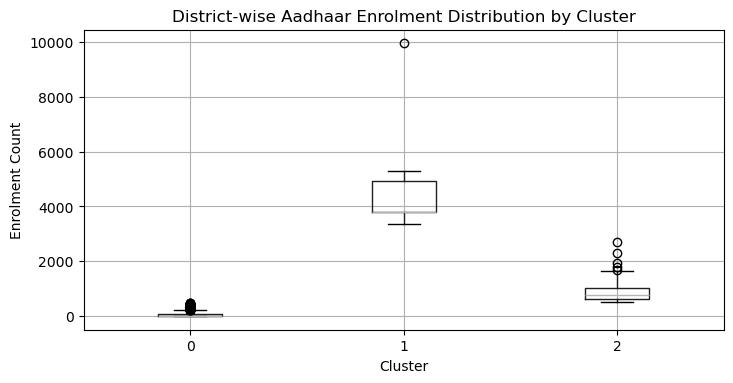

In [150]:
# District-wise Aadhaar Enrolment Distribution by Cluster
district_data.boxplot(
    column='age_18_greater',
    by='cluster',
    figsize=(8,4)
)
plt.title("District-wise Aadhaar Enrolment Distribution by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Enrolment Count")
plt.show()


## Time Series Forecasting

In [151]:
enrolment_df['date'] = pd.to_datetime(
    enrolment_df['date'],
    errors='coerce'
)

enrolment_df['date'].dtype


dtype('<M8[ns]')

In [152]:

monthly_total = enrolment_df.groupby(
    enrolment_df['date'].dt.to_period('M')
)[['age_0_5','age_5_17','age_18_greater']].sum()



In [153]:
monthly_total.index = monthly_total.index.to_timestamp()

In [154]:
from sklearn.linear_model import LinearRegression


X = np.arange(len(monthly_total)).reshape(-1, 1)
y = monthly_total.values

In [155]:
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [156]:
future_X = np.arange(len(monthly_total), len(monthly_total) + 6).reshape(-1, 1)
forecast = model.predict(future_X)


C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_27136\1362268924.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(monthly_total.index[-1], periods=7, freq='M')[1:],


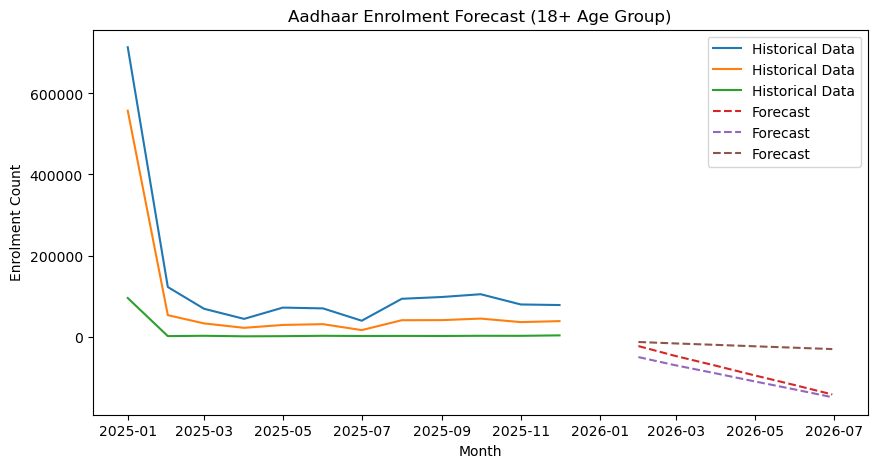

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_total.index, y, label="Historical Data")
plt.plot(
    pd.date_range(monthly_total.index[-1], periods=7, freq='M')[1:],
    forecast,
    label="Forecast",
    linestyle='--'
)
plt.legend()
plt.title("Aadhaar Enrolment Forecast (18+ Age Group)")
plt.xlabel("Month")
plt.ylabel("Enrolment Count")
plt.show()
